In [1]:
!pip -q install nltk scikit-learn pandas seaborn joblib

import nltk

for resource in ["twitter_samples", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource)

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import twitter_samples, stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [3]:
def clean_tweet(text):
    text = text.lower()

    # Remove URLs, user mentions and retweet marker
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\brt\b", " ", text)

    # Keep hashtag words but remove the # symbol
    text = text.replace("#", "")

    # Remove punctuation and numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(tokens)

In [4]:
positive_tweets = twitter_samples.strings("positive_tweets.json")
negative_tweets = twitter_samples.strings("negative_tweets.json")

texts = positive_tweets + negative_tweets
labels = [1] * len(positive_tweets) + [0] * len(negative_tweets)

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

df.head()

,text,label
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1
1,@Lamb2ja Hey James! How odd :/ Please call our...,1
2,@DespiteOfficial we had a listen last night :)...,1
3,@97sides CONGRATS :),1
4,yeaaaah yippppy!!! my accnt verified rqst has...,1


In [5]:
df["clean_text"] = df["text"].apply(clean_tweet)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())

df.head()

Dataset shape: (10000, 3)
label
1    5000
0    5000
Name: count, dtype: int64


,text,label,clean_text
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,1,followfriday top engaged member community week
1,@Lamb2ja Hey James! How odd :/ Please call our...,1,hey james odd please call contact centre able ...
2,@DespiteOfficial we had a listen last night :)...,1,listen last night bleed amazing track scotland
3,@97sides CONGRATS :),1,congrats
4,yeaaaah yippppy!!! my accnt verified rqst has...,1,yeaaaah yippppy accnt verified rqst succeed go...


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []
trained_models = {}
predictions = {}

for name, classifier in models.items():

    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=15000
            )
        ),
        ("model", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7635,0.781217,0.732,0.755808
1,Multinomial Naive Bayes,0.7485,0.780158,0.692,0.733439
2,Linear SVM,0.7385,0.747150,0.721,0.733842


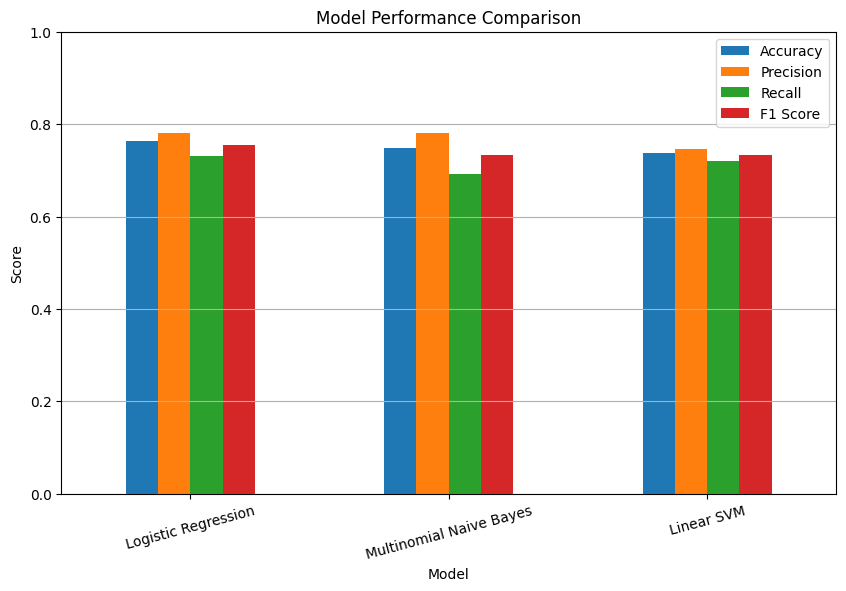

In [8]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

In [9]:
best_row = results_df.loc[results_df["F1 Score"].idxmax()]
best_model_name = best_row["Model"]

best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, best_predictions))

Best model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.80      0.77      1000
           1       0.78      0.73      0.76      1000

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



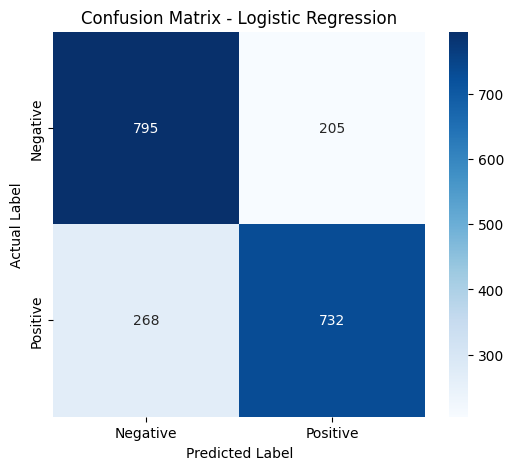

In [10]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [11]:
def predict_sentiment(text):
    cleaned_text = clean_tweet(text)
    prediction = best_model.predict([cleaned_text])[0]

    return "Positive 😊" if prediction == 1 else "Negative 😞"

In [12]:
examples = [
    "I absolutely love this product!",
    "This was the worst experience ever.",
    "The service was excellent and very helpful.",
    "I am disappointed with the quality."
]

for sentence in examples:
    print(sentence)
    print("Prediction:", predict_sentiment(sentence))
    print()

I absolutely love this product!
Prediction: Positive 😊

This was the worst experience ever.
Prediction: Negative 😞

The service was excellent and very helpful.
Prediction: Positive 😊

I am disappointed with the quality.
Prediction: Negative 😞



In [13]:
joblib.dump(
    best_model,
    "twitter_sentiment_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.
